In [1]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Importing the trial dataset for the first subject

In [693]:
subject_1_train_raw = mne.io.read_raw_gdf("../dataset/BCICIV_2a_gdf/A01T.gdf", verbose=False, preload=True)

c:\Users\akila\AppData\Local\Programs\Python\Python314\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


In [694]:
subject_1_train_raw.annotations.description

array(['32766', '276', '32766', '277', '32766', '1072', '32766', '768',
       '772', '768', '771', '768', '770', '768', '769', '768', '769',
       '768', '770', '768', '771', '768', '772', '768', '770', '768',
       '771', '768', '769', '768', '769', '768', '769', '768', '772',
       '768', '770', '768', '770', '768', '769', '768', '769', '768',
       '771', '768', '769', '768', '770', '768', '1023', '772', '768',
       '772', '768', '771', '768', '769', '768', '772', '768', '772',
       '768', '770', '768', '772', '768', '772', '768', '770', '768',
       '769', '768', '770', '768', '771', '768', '771', '768', '771',
       '768', '772', '768', '771', '768', '769', '768', '772', '768',
       '770', '768', '771', '768', '770', '768', '771', '768', '772',
       '768', '1023', '770', '768', '771', '768', '769', '32766', '768',
       '769', '768', '769', '768', '772', '768', '770', '768', '1023',
       '769', '768', '771', '768', '769', '768', '771', '768', '1023',
       '770'

In [695]:
data, times = subject_1_train_raw[:]

In [696]:
print(subject_1_train_raw.ch_names)
print(subject_1_train_raw.get_channel_types())

['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']
['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']


In [697]:
eog_chs = subject_1_train_raw.ch_names[-3:] 
subject_1_train_raw.set_channel_types({ch: 'eog' for ch in eog_chs})

<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~128.3 MiB, data loaded>

In [698]:
ch_names_2a = ['Fz','FC3','FC1','FCz','FC2','FC4','C5','C3','C1','Cz', 'C2','C4','C6','CP3','CP1','CPz','CP2','CP4','P1','Pz','P2','POz','EOG-left','EOG-central','EOG-right']
subject_1_train_raw.rename_channels(dict(zip(subject_1_train_raw.ch_names, ch_names_2a)))

<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~128.3 MiB, data loaded>

In [699]:
print(set(subject_1_train_raw.annotations.description))

{np.str_('276'), np.str_('1072'), np.str_('1023'), np.str_('768'), np.str_('771'), np.str_('772'), np.str_('277'), np.str_('770'), np.str_('32766'), np.str_('769')}


In [700]:
marker_label = {
    1: "Rejected Trial", 
    2: "Eye movments",
    3: "Idling EEG (eyes open)",
    4: "Idling EEG (eyes closed)", \
    5: "Start of a new run",
    6: "Start of a trial",
    7: "left_hand", 
    8: "right_hand",
    9: "feet", 
    10: "tongue"
}

In [701]:
subject_1_train_raw.annotations.description = np.array(
    [marker_label.get(d, d) for d in subject_1_train_raw.annotations.description]
)

In [711]:
subject_1_train_raw.filter(l_freq=13, h_freq=30)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 13 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 13.00
- Lower transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 11.38 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 255 samples (1.020 s)



<RawGDF | A01T.gdf, 25 x 672528 (2690.1 s), ~128.3 MiB, data loaded>

In [712]:
events, event_id = mne.events_from_annotations(subject_1_train_raw, verbose=False)
print(event_id)
print(events)

{np.str_('1023'): 1, np.str_('1072'): 2, np.str_('276'): 3, np.str_('277'): 4, np.str_('32766'): 5, np.str_('768'): 6, np.str_('769'): 7, np.str_('770'): 8, np.str_('771'): 9, np.str_('772'): 10}
[[     0      0      5]
 [     0      0      3]
 [ 29683      0      5]
 ...
 [670550      0      6]
 [670550      0      1]
 [671050      0      7]]


In [713]:
mi_event_id = {marker_label[v]: v for k, v in event_id.items() if marker_label[v] in ['left_hand', 'right_hand', 'feet', 'tongue']}
print(mi_event_id)

{'left_hand': 7, 'right_hand': 8, 'feet': 9, 'tongue': 10}


In [714]:
epochs = mne.Epochs(subject_1_train_raw, events, event_id=mi_event_id, tmin=-0.5, tmax=5.25, baseline=None, preload=True)

X = epochs.get_data()        
y = epochs.events[:, -1]     

Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1438 original time points ...
0 bad epochs dropped


In [715]:
print(epochs.event_id)
print(epochs)

{'left_hand': 7, 'right_hand': 8, 'feet': 9, 'tongue': 10}
<Epochs | 288 events (all good), -0.5 – 5.248 s (baseline off), ~79.0 MiB, data loaded,
 'left_hand': 72
 'right_hand': 72
 'feet': 72
 'tongue': 72>


In [716]:
print(epochs['left_hand'].get_data().shape)
print(epochs['right_hand'].get_data().shape)
print(epochs['feet'].get_data().shape)
print(epochs['tongue'].get_data().shape)

(72, 25, 1438)
(72, 25, 1438)
(72, 25, 1438)
(72, 25, 1438)


In [717]:
epochs_mi = epochs.copy().crop(tmin=0.5, tmax=4)
epochs_mi.pick_types(eeg=True)
X = epochs_mi.get_data()   # shape (n_trials, n_eeg_channels, n_times)
y = epochs_mi.events[:, -1]

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


In [718]:
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

binary_mask = np.isin(y, [mi_event_id['left_hand'], mi_event_id['right_hand']])
X_bin = X[binary_mask]
y_bin = y[binary_mask]

csp = CSP(n_components=6, reg=None, log=True, norm_trace=False)
lda = LinearDiscriminantAnalysis()
clf = Pipeline([('CSP', csp), ('LDA', lda)])

scores = cross_val_score(clf, X_bin, y_bin, cv=5)
scores
print(scores, scores.mean())

Computing rank from data with rank=None


    Using tolerance 2.5e-05 (2.2e-16 eps * 22 dim * 5.1e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.5e-05 (2.2e-16 eps * 22 dim * 5.1e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.5e-05 (2.2e-16 eps * 22 dim * 5.1e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covarian

Computing rank from data with rank=None
    Using tolerance 2.6e-05 (2.2e-16 eps * 22 dim * 5.4e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.6e-05 (2.2e-16 eps * 22 dim * 5.4e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.6e-05 (2.2e-16 eps * 22 dim * 5.4e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMP

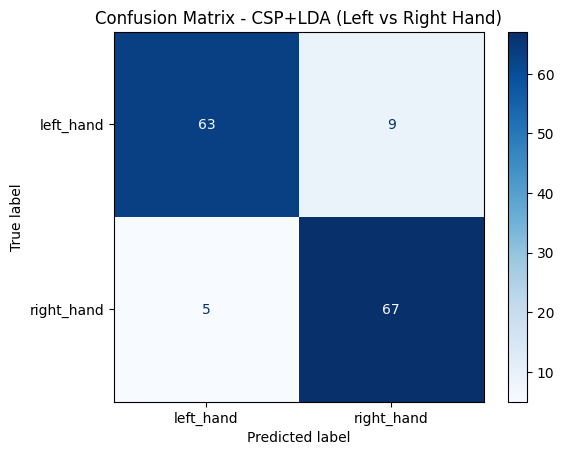

              precision    recall  f1-score   support

   left_hand       0.93      0.88      0.90        72
  right_hand       0.88      0.93      0.91        72

    accuracy                           0.90       144
   macro avg       0.90      0.90      0.90       144
weighted avg       0.90      0.90      0.90       144



In [719]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
y_pred = cross_val_predict(clf, X_bin, y_bin, cv=cv)

cm = confusion_matrix(y_bin, y_pred)
print(cm)


class_labels = ['left_hand', 'right_hand'] 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - CSP+LDA (Left vs Right Hand)')
plt.show()

print(classification_report(y_bin, y_pred, target_names=class_labels))

In [720]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

binary_mask = np.isin(y, [mi_event_id['left_hand'], mi_event_id['right_hand']])
X_bin = X[binary_mask]
y_bin = y[binary_mask]

svm = SVC(kernel='rbf')
param_grid = {
    'SVM__C': [0.1, 1, 10],
    'SVM__gamma': ['scale', 0.01, 0.1]
}
clf_svm = Pipeline([('CSP', csp), ('SVM', svm)])

grid = GridSearchCV(clf_svm, param_grid, cv=5)
grid.fit(X_bin, y_bin)
print(grid.best_params_, grid.best_score_)

Computing rank from data with rank=None


    Using tolerance 2.5e-05 (2.2e-16 eps * 22 dim * 5.1e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.5e-05 (2.2e-16 eps * 22 dim * 5.1e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.5e-05 (2.2e-16 eps * 22 dim * 5.1e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=7 covariance using EMPIRICAL
Done.
Estimating class=8 covarian

In [ ]:
import matplotlib.pyplot as plt
import mne
from mne.time_frequency import tfr_morlet
import numpy as np

epochs_eeg = epochs.copy().pick_types(eeg=True)
montage = mne.channels.make_standard_montage('standard_1020')
epochs_eeg.set_montage(montage, match_case=False, on_missing='ignore')

print(f"Number of dig points: {len(epochs_eeg.info['dig'])}")
print(f"Channel names: {epochs_eeg.ch_names}")


freqs = np.arange(8, 30, 2)
n_cycles = freqs / 2.

power = tfr_morlet(epochs_eeg, freqs=freqs, n_cycles=n_cycles,
                    use_fft=True, return_itc=False, average=False)

power.apply_baseline(baseline=(-0.5, 0), mode='percent')
print(power.data.min(), power.data.max())

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Number of dig points: 25
Channel names: ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
-0.9999999999429466 476.590147262726


No baseline correction applied


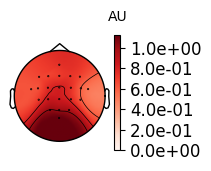

In [ ]:
fig = power['left_hand'].average().plot_topomap(
    tmin=0.5, tmax=3.5, fmin=8, fmax=30
)
fig.suptitle('ERD - left_hand')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.time_frequency import tfr_morlet


epochs_padded = mne.Epochs(raw, events, event_id=mi_event_id,
                            tmin=-1.5, tmax=6.0, baseline=None, preload=True)
epochs_eeg = epochs_padded.copy().pick_types(eeg=True)

montage = mne.channels.make_standard_montage('standard_1020')
epochs_eeg.set_montage(montage, match_case=False, on_missing='ignore')


freqs = np.arange(8, 13, 1)
n_cycles = freqs / 2.

power_left = tfr_morlet(epochs_eeg['left_hand'], freqs=freqs, n_cycles=n_cycles, use_fft=True, return_itc=False, average=True)

power_left.crop(tmin=-0.5, tmax=4.0)

power_left.apply_baseline(baseline=(-0.5, 0), mode='percent')

print("min/max after fix:", power_left.data.min(), power_left.data.max())

Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1876 original time points ...
0 bad epochs dropped
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
min/max after fix: -0.3132812193531091 0.8174434685100705


No baseline correction applied


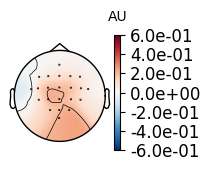

In [690]:
fig = power_left.plot_topomap(
    tmin=0.5, tmax=3.5, fmin=8, fmax=13,
    vlim=(-0.6, 0.6), cmap='RdBu_r'
)
fig.suptitle('ERD - left_hand (blue = power decrease)')
plt.show()

Not setting metadata
288 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 288 events and 1876 original time points ...
1 bad epochs dropped
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
Applying baseline correction (mode: percent)
left  min/max: -0.5720692149110813 0.7213334900411391
right min/max: -0.5668412068232236 0.4691921149191378
No baseline correction applied
No baseline correction applied


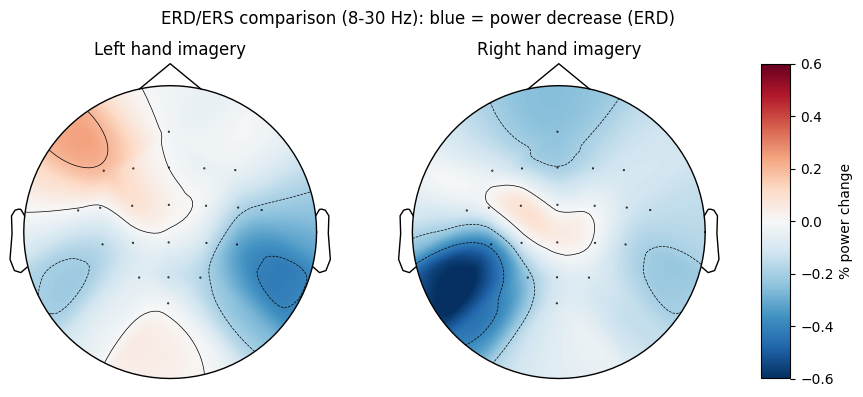

In [722]:
import numpy as np
import matplotlib.pyplot as plt
import mne
from mne.time_frequency import tfr_morlet

epochs_padded = mne.Epochs(raw, events, event_id=mi_event_id,
                            tmin=-1.5, tmax=6.0, baseline=None, preload=True)
epochs_eeg = epochs_padded.copy().pick_types(eeg=True)

montage = mne.channels.make_standard_montage('standard_1020')
epochs_eeg.set_montage(montage, match_case=False, on_missing='ignore')

freqs = np.arange(8, 13, 2)
n_cycles = freqs / 2.

def get_class_power(epochs_eeg, class_name):
    p = tfr_morlet(epochs_eeg[class_name], freqs=freqs, n_cycles=n_cycles,
                    use_fft=True, return_itc=False, average=True)
    p.crop(tmin=-0.5, tmax=4.0)
    p.apply_baseline(baseline=(-0.5, 0), mode='percent')
    return p

power_left = get_class_power(epochs_eeg, 'left_hand')
power_right = get_class_power(epochs_eeg, 'right_hand')

print("left  min/max:", power_left.data.min(), power_left.data.max())
print("right min/max:", power_right.data.min(), power_right.data.max())

fig, axes = plt.subplots(1, 3, figsize=(9, 4), gridspec_kw={'width_ratios': [1, 1, 0.08]})

vlim = (-0.6, 0.6)

power_left.plot_topomap(
    tmin=0.5, tmax=3.5, fmin=8, fmax=13,
    vlim=vlim, cmap='RdBu_r',
    axes=axes[0], colorbar=False, show=False
)
axes[0].set_title('Left hand imagery')

power_right.plot_topomap(
    tmin=0.5, tmax=3.5, fmin=8, fmax=13,
    vlim=vlim, cmap='RdBu_r',
    axes=axes[1], colorbar=False, show=False
)
axes[1].set_title('Right hand imagery')


norm = plt.Normalize(vmin=vlim[0], vmax=vlim[1])
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
fig.colorbar(sm, cax=axes[2], label='% power change')

fig.suptitle('ERD/ERS comparison (8-30 Hz): blue = power decrease (ERD)')
plt.tight_layout()
plt.show()